# Laser power noise: DARK vs ON at two powers — the 0.3–10 mHz band

Power noise of the imaging laser from the `RDS-PD_IN1` monitor, in **absolute power
units referred to the chamber**, against the thermal-torque requirement — with an
**independent Ophir power-meter record over the same window** as a cross-check, at
**two operating powers** (~3 mW and ~10 mW).

**Where the requirement comes from.** Thermal kicks and laser power fluctuations both
enter the rotor as *torques*, and both are shaped by the same mechanical response
$|\chi(f)| = 1/(I\sqrt{\gamma^2+(2\pi f)^2})$. The response cancels from the
comparison, so the requirement is a torque-vs-torque statement, **independent of
Fourier frequency**:

$$\delta P_{\rm req} \;=\; \frac{\sqrt{4k_BT\gamma I}}{\partial N/\partial P}
\;\approx\; 0.74\ \mu\mathrm{W}/\sqrt{\mathrm{Hz}}$$

---

## Why two powers

The requirement is fixed in **absolute** µW/√Hz — $\partial N/\partial P$ is a geometric
constant — so it does **not** relax at higher power. What the second power settles is
whether the noise is *multiplicative* or *additive*:

| | absolute ASD | RIN |
|---|---|---|
| **multiplicative** (RIN, transmission drift) | scales $\propto P$ | the two runs **overlay** |
| **additive** (detector floor, electronics) | unchanged | falls $\propto 1/P$ |

The DARK record already showed the additive floor is small, so the expectation is
multiplicative — but "multiplicative" covers *both* real laser RIN and any drifting
transmission between laser and diode, which scale identically. This test therefore
answers "does the absolute noise get worse at operating power?", **not** "is it the
laser or the optics". The independent meter is what separates those.

## Method, following `laser_rin.ipynb` / `rotor_stability_flat.ipynb`

- **Low-frequency Welch**: block-average to 1 Hz, remove **one global linear trend**
  from the whole record, then `welch` with its default per-segment mean removal — the
  convention of `laser_rin.ipynb` c9 and `rotor_stability_flat.ipynb` c15. *Not*
  `detrend='linear'`, which detrends each segment and would eat power near
  $f \approx 1/T_{\rm seg}$.
- **10000 s segments** → 0.1 mHz resolution, trustworthy to **0.3 mHz** by the
  `f_ok = 3/T_seg` convention.
- **Data-quality gate first** (`laser_rin.ipynb` c5). Deliberate beam blocks (timing
  fiducials against the meter's independent clock) and the laser turn-on are both
  removed *before* any spectrum is taken. Leaving the turn-on in inflates the record's
  variance by an order of magnitude and leaks into the lowest bins — that artefact is
  what previously produced a spurious 305 µW/√Hz at 3–10 mHz and an apparent 14×
  PD-vs-meter disagreement. Neither survives the gate.

### Calibration caution

κ quoted in **N·m per PD count** is valid only at its own PD gain. Everything here is
converted to physical power first, using **each record's own** counts/mW taken from its
own meter log, and torque is taken per **mW**, which is gain-independent. Comparing the
two runs' counts/mW is also a free **PD linearity check**.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
from datetime import datetime, timezone
from scipy.signal import welch, find_peaks, correlate
from scipy.ndimage import median_filter, uniform_filter1d

DBX = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER'

# ------------------------------------------------------------------ the runs
# Each ON run carries its own meter log, so each recalibrates itself.
RUNS = [
    dict(name='3.03 mW', short='3mW',  color='darkorange', mcolor='seagreen',
         h5=f'{DBX}/data/PD/Y1_RDS-PD_IN1_DQ_1469307101_1469386301.h5',
         meter=f'{DBX}/laser_power/260728_laser_power.txt'),
    dict(name='10.4 mW', short='10mW', color='crimson',    mcolor='teal',
         h5=f'{DBX}/data/PD/Y1_RDS-PD_IN1_DQ_1469559972_1469667972.h5',
         meter=f'{DBX}/laser_power/260731_laser_power_10mW.txt'),
]
DARK_H5 = f'{DBX}/data/PD/Y1_RDS-PD_IN1_DQ_1469220701_1469299901.h5'   # laser off, 22 h

# ------------------------------------------------------------------ tunables
FS_LO      = 1.0        # Hz  -- block-averaged rate for the low-f estimate
SEG_LO_S   = 10000.0    # s   -- low-f Welch segment: 0.1 mHz res, trust > 0.3 mHz
NPERSEG_HI = 16384      # 16 s segments for the high-f estimate
HI_HOURS   = 3.0        # h   -- full-rate data kept (the gate eats into it)
CHUNK      = 4_000_000  # samples per read (~16 MB float32)

GLITCH_NSIGMA = 8.0
GLITCH_PAD    = 16
SETTLE_FRAC   = 0.02    # "settled" = within this fraction of the late-record median
SETTLE_GUARD  = 60.0    # s discarded after the last unsettled sample
BLOCK_FRAC    = 0.5     # beam block = below this fraction of the median
BLOCK_MIN_S   = 3.0     # s -- shortest run counted as a deliberate block
BLOCK_GUARD   = 30.0    # s excluded either side of a block

# ------------------------------------------------------------------ constants
GPS_UNIX_OFFSET = 315964800 - 18
def gps_to_dt(g):
    return datetime.fromtimestamp(g + GPS_UNIX_OFFSET, tz=timezone.utc)

KB_J, T_BATH = 1.380649e-23, 300.0
I_KGM2     = 1.88e-11
TAU_FREE_S = 67.65 * 60.0
GAMMA      = 1.0 / TAU_FREE_S
S_N_THERMAL = np.sqrt(4 * KB_J * T_BATH * GAMMA * I_KGM2)

KAPPA_PD_OLD   = 7.3499e-16
CTS_PER_MW_OLD = 167.6 / 10.34
TORQUE_PER_MW  = KAPPA_PD_OLD * CTS_PER_MW_OLD
REQ_UW    = S_N_THERMAL / TORQUE_PER_MW * 1e3
TARGET_UW = 1.0
E_CHARGE, RESPONSIVITY = 1.602176634e-19, 0.7

print(f'thermal torque noise : {S_N_THERMAL:.3e} N m/sqrt(Hz)')
print(f'torque per mW        : {TORQUE_PER_MW:.3e} N m/mW')
print(f'=> REQUIREMENT       : {REQ_UW:.3f} uW/sqrt(Hz)  (frequency-independent)')
print(f'low-f estimate       : {SEG_LO_S:.0f} s segments -> {1/SEG_LO_S*1e3:.3f} mHz'
      f' resolution, trust above {3/SEG_LO_S*1e3:.2f} mHz')

thermal torque noise : 8.760e-18 N m/sqrt(Hz)
torque per mW        : 1.191e-14 N m/mW
=> REQUIREMENT       : 0.735 uW/sqrt(Hz)  (frequency-independent)
low-f estimate       : 10000 s segments -> 0.100 mHz resolution, trust above 0.30 mHz


## 1. Loaders and the data-quality gate

The records are 22–30 h at 1024 Hz (80–110 M samples), so the loader **streams**: it
reads in chunks, deglitches at full rate, and block-averages to `FS_LO` as it goes,
never holding a whole record in memory.

**The gate has three stages, in order.** Beam blocks are found *first* — they are
deliberate, they are the timing fiducials, and they are not glitches. The analysis span
is then the **longest contiguous stretch containing no block**, which handles blocks at
the start *and* the end (trimming "to after the last block" would throw away the whole
record when a block closes it). Settling detection runs inside that span.

In [2]:
def block_average(y, d):
    m = (len(y) // d) * d
    return y[:m].reshape(-1, d).mean(axis=1) if m else np.empty(0, y.dtype)


def deglitch_chunk(y, fs, nsigma=GLITCH_NSIGMA, pad=GLITCH_PAD):
    """O(N) glitch repair: box-smoothed baseline, robust sigma from a decimated
    residual, flagged samples replaced by the baseline."""
    base  = uniform_filter1d(y, size=int(2 * fs), mode='nearest')
    resid = y - base
    sub   = resid[::16]
    sigma = np.median(np.abs(sub - np.median(sub))) * 1.4826
    flag  = np.abs(resid) > nsigma * sigma if sigma > 0 else np.zeros(len(y), bool)
    n = int(flag.sum())
    if n:
        if pad:
            flag = uniform_filter1d(flag.astype(np.float32), size=2 * pad + 1) > 0
        y = y.copy()
        y[flag] = base[flag]
    return y, n, float(sigma)


def stream_load(path, fs_lo=FS_LO, hi_seconds=HI_HOURS * 3600, do_deglitch=True):
    """Segment-aware streaming read -> 1 Hz series + the first `hi_seconds` at full rate."""
    lo_parts, hi_parts, n_gl, sigmas = [], [], 0, []
    with h5py.File(path, 'r') as f:
        fs  = float(f.attrs['sample_rate'])
        dec = int(round(fs / fs_lo))
        hi_need = int(hi_seconds * fs)
        g0s = f['segments/gps_start'][:].astype(np.float64)
        ixs = f['segments/index_start'][:].astype(np.int64)
        lns = f['segments/length'][:].astype(np.int64)
        order = np.argsort(g0s)
        t0, total, dset = float(g0s[order[0]]), 0, f['data']
        for si in order:
            ix, n = int(ixs[si]), int(lns[si])
            total += n
            carry = np.empty(0, np.float32)
            for c0 in range(0, n, CHUNK):
                y = dset[ix + c0: ix + min(c0 + CHUNK, n)].astype(np.float32)
                if do_deglitch:
                    y, ng, sg = deglitch_chunk(y, fs)
                    n_gl += ng; sigmas.append(sg)
                have = sum(len(h) for h in hi_parts)
                if have < hi_need:
                    hi_parts.append(y[:hi_need - have].copy())
                y = np.concatenate([carry, y]) if len(carry) else y
                k = (len(y) // dec) * dec
                lo_parts.append(block_average(y[:k], dec))
                carry = y[k:].copy()
    y_lo = np.concatenate(lo_parts)
    return dict(t0=t0, fs=fs, dur=total / fs, y_lo=y_lo, fs_lo=fs_lo,
                y_hi=np.concatenate(hi_parts) if hi_parts else np.empty(0, np.float32),
                n_glitch=n_gl, sigma=float(np.median(sigmas)) if sigmas else 0.0,
                level=float(np.median(y_lo)))


def parse_starlab(path):
    """Ophir StarLab log -> (t_elapsed_s, power_mW, header stats dict)."""
    t, p, stats = [], [], {}
    with open(path, 'r', errors='replace') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            if s[0] in ';!':
                for key in ('Average', 'Std.Dev.', 'Min', 'Max', 'Duration', 'Total'):
                    if s.lstrip(';').startswith(key + ':'):
                        stats[key] = s.split(':', 1)[1].strip()
                continue
            q = s.split()
            if len(q) >= 2:
                try:
                    t.append(float(q[0])); p.append(float(q[1]) * 1e3)
                except ValueError:
                    pass
    return np.asarray(t), np.asarray(p), stats


def find_beam_blocks(y, fs, frac=BLOCK_FRAC, min_dur_s=BLOCK_MIN_S):
    """Contiguous runs below `frac` x median -- deliberate beam blocks (fiducials)."""
    med = np.median(y)
    if med <= 0:
        return []
    low = y < frac * med
    if not low.any():
        return []
    e = np.flatnonzero(np.diff(np.r_[0, low.astype(np.int8), 0]))
    out = []
    for a, b in zip(e[::2], e[1::2]):
        if (b - a) / fs >= min_dur_s:
            out.append(dict(start_s=a / fs, end_s=b / fs, dur_s=(b - a) / fs,
                            depth_frac=float(np.median(y[a:b]) / med)))
    return out


def longest_clean_span(n, fs, blocks, guard_s=BLOCK_GUARD):
    """Longest contiguous [i0, i1) containing no beam block (plus guard either side).
    Blocks at the START and the END are both handled -- trimming simply to 'after the
    last block' would discard everything when a block closes the record."""
    cut = [(0, 0)]
    for b in blocks:
        cut.append((max(0, int((b['start_s'] - guard_s) * fs)),
                    min(n, int((b['end_s'] + guard_s) * fs))))
    cut.append((n, n))
    cut.sort()
    best = (0, 0)
    for (_, e1), (s2, _) in zip(cut[:-1], cut[1:]):
        if s2 - e1 > best[1] - best[0]:
            best = (e1, s2)
    return best


def match_fiducials(bp, bm, align_tol=5.0):
    """Align two block lists that need NOT contain the same set of blocks -- one record
    routinely starts later than the other, so pairing first-with-first is wrong.

    Every candidate pairing gives a trial offset; the winner is the offset supported by
    the most co-aligned block pairs, with closest duration match as the tie-break.
    Returns (offset_s, pairs) with meter_t = pd_t + offset."""
    if not bp or not bm:
        return None, []
    best = None
    for i, p in enumerate(bp):
        for j, m in enumerate(bm):
            off = m['start_s'] - p['start_s']
            pairs = [(ii, jj) for ii, pp in enumerate(bp) for jj, mm in enumerate(bm)
                     if abs((mm['start_s'] - pp['start_s']) - off) < align_tol]
            score = (len(pairs), -abs(p['dur_s'] - m['dur_s']))
            if best is None or score > best[0]:
                best = (score, off, sorted(set(pairs)))
    return best[1], best[2]


def find_settled_start(y, fs, settle_frac=SETTLE_FRAC, guard_s=SETTLE_GUARD,
                       smooth_s=10.0, name=''):
    """Index at which the record is settled (0 if it always was).

    Threshold is `settle_frac` of the late-record median OR 5 robust sigma of the late
    record, whichever is larger. The sigma term matters for the DARK record, whose
    median is ~0 -- a pure fraction-of-median test would flag every sample there."""
    n   = len(y)
    if n < 10:
        return 0
    ref = np.median(y[n // 2:])
    lat = y[n // 2:]
    sig = float(np.median(np.abs(lat - ref)) * 1.4826)
    thr = max(abs(settle_frac * ref), 5.0 * sig)
    if thr <= 0:
        return 0
    sm  = uniform_filter1d(y.astype(np.float64), size=max(1, int(smooth_s * fs)))
    bad = np.abs(sm - ref) > thr
    if not bad.any():
        return 0
    i = min(n - 1, int(np.flatnonzero(bad)[-1] + guard_s * fs))
    if i > n // 2:
        print(f'  WARNING [{name}]: settling scan flagged {i/3600:.2f} h (> half the '
              f'record); treating as detection failure, using 0.')
        return 0
    return i


def gate(y, fs, name):
    """Full data-quality gate -> (i0, i1, blocks). Blocks first, then longest clean
    span, then settling inside it."""
    blocks = find_beam_blocks(y, fs)
    i0, i1 = longest_clean_span(len(y), fs, blocks)
    i0 += find_settled_start(y[i0:i1], fs, name=name)
    return i0, i1, blocks

## 2. Load, gate, calibrate

Each run's counts/mW comes from its own meter log over its own settled span, so the
calibration is valid at whatever power that run sat at.

In [3]:
print('loading DARK ...')
dk = stream_load(DARK_H5)
dk_i0, dk_i1, dk_blocks = gate(dk['y_lo'], FS_LO, 'DARK')
dk_y = dk['y_lo'][dk_i0:dk_i1]

for r in RUNS:
    print(f'loading {r["name"]} ...')
    r['pd'] = stream_load(r['h5'])
    r['tm'], r['pm'], r['pstats'] = parse_starlab(r['meter'])
    # meter on a uniform 1 Hz grid (samples are ~15 Hz but not exactly uniform)
    r['gp']   = np.arange(r['tm'][0], r['tm'][-1], 1.0 / FS_LO)
    r['pm_1'] = np.interp(r['gp'], r['tm'], r['pm'])
    r['pd_i0'], r['pd_i1'], r['pd_blocks'] = gate(r['pd']['y_lo'], FS_LO, f'{r["short"]} PD')
    r['m_i0'],  r['m_i1'],  r['m_blocks']  = gate(r['pm_1'],       FS_LO, f'{r["short"]} meter')
    r['pd_y'] = r['pd']['y_lo'][r['pd_i0']:r['pd_i1']]
    r['m_y']  = r['pm_1'][r['m_i0']:r['m_i1']]
    r['P_mW'] = float(np.mean(r['m_y']))
    r['cts_per_mW'] = float(np.median(r['pd_y'])) / r['P_mW']
print('done.\n')

print('== data-quality gate ==')
for tag, y, i0, i1, blocks in ([('DARK', dk['y_lo'], dk_i0, dk_i1, dk_blocks)] +
        [(f'{r["short"]} PD', r['pd']['y_lo'], r['pd_i0'], r['pd_i1'], r['pd_blocks']) for r in RUNS] +
        [(f'{r["short"]} meter', r['pm_1'], r['m_i0'], r['m_i1'], r['m_blocks']) for r in RUNS]):
    print(f'  {tag:12s}: {len(y)/3600:5.2f} h raw -> analysis span '
          f'{i0/3600:5.2f}-{i1/3600:5.2f} h ({(i1-i0)/3600:5.2f} h), '
          f'{len(blocks)} beam block(s)')
    for b in blocks:
        print(f'        block at t={b["start_s"]:9.1f} s  dur={b["dur_s"]:5.1f} s  '
              f'depth={b["depth_frac"]:.3f}')

print('\n== calibration ==')
print(f'  DARK  : {gps_to_dt(dk["t0"]):%Y-%m-%d %H:%M} UTC, level {np.median(dk_y):.2f} counts, '
      f'{dk["n_glitch"]:,} glitches')
for r in RUNS:
    print(f'  {r["name"]:8s}: {gps_to_dt(r["pd"]["t0"]):%Y-%m-%d %H:%M} UTC, '
          f'{r["pd"]["dur"]/3600:.2f} h, PD {np.median(r["pd_y"]):7.1f} cts, '
          f'meter {r["P_mW"]:6.3f} mW -> {r["cts_per_mW"]:6.1f} counts/mW, '
          f'{r["pd"]["n_glitch"]:,} glitches')

# free PD linearity check: same chain, two powers
a, b = RUNS[0], RUNS[1]
dev = (b['cts_per_mW'] / a['cts_per_mW'] - 1) * 100
print(f'\n  PD linearity: {a["cts_per_mW"]:.1f} vs {b["cts_per_mW"]:.1f} counts/mW '
      f'over {a["P_mW"]:.2f} -> {b["P_mW"]:.2f} mW  =>  {dev:+.1f}% deviation')
print('  (a few % is calibration scatter; a large number means the PD is not linear')
print('   across this range and per-run calibration is mandatory, not optional.)')

loading DARK ...
loading 3.03 mW ...
loading 10.4 mW ...
done.

== data-quality gate ==
  DARK        : 22.00 h raw -> analysis span  0.47-22.00 h (21.53 h), 0 beam block(s)
  3mW PD      : 22.00 h raw -> analysis span  0.23-22.00 h (21.77 h), 3 beam block(s)
        block at t=      0.0 s  dur= 32.0 s  depth=0.091
        block at t=     34.0 s  dur= 40.0 s  depth=0.025
        block at t=    784.0 s  dur=  3.0 s  depth=0.099
  10mW PD     : 30.00 h raw -> analysis span  0.00-29.95 h (29.95 h), 1 beam block(s)
        block at t= 107849.0 s  dur= 10.0 s  depth=-0.000
  3mW meter   : 21.75 h raw -> analysis span  0.00-21.75 h (21.75 h), 0 beam block(s)
  10mW meter  : 32.51 h raw -> analysis span  0.89-32.48 h (31.59 h), 3 beam block(s)
        block at t=   3100.0 s  dur= 17.0 s  depth=0.000
        block at t=   3149.0 s  dur= 12.0 s  depth=0.000
        block at t= 116963.0 s  dur= 11.0 s  depth=0.000

== calibration ==
  DARK  : 2026-07-27 20:51 UTC, level -0.78 counts, 0 glitches


## 3. Spectra

Low-frequency estimate from the whole gated record at 1 Hz with 10000 s segments;
high-frequency estimate from the gated portion of the full-rate slice with 16 s
segments. The gate applies to **both** — leaving the turn-on in the full-rate slice
puts a spurious step at the seam between the two estimates.

In [4]:
def detrend_global_linear(y, fs):
    """One global straight line off the whole record, then welch's default per-segment
    mean removal. Returns (detrended, slope per hour)."""
    ts = np.arange(len(y)) / fs
    c  = np.polyfit(ts, y, 1)
    return y - np.polyval(c, ts), c[0] * 3600.0


def asd_lowf(y, fs, seg_s=SEG_LO_S):
    yd, slope_h = detrend_global_linear(y, fs)
    f, P = welch(yd, fs=fs, nperseg=int(seg_s * fs))
    return f, P, slope_h, len(yd) / (seg_s * fs / 2) - 1


f_lo, P_dk_lo, sl_dk, navg_dk = asd_lowf(dk_y, FS_LO)
dk_hi = dk['y_hi'][int(dk_i0 * dk['fs']):]
f_hi, P_dk_hi = welch(dk_hi.astype(np.float64) - dk_hi.mean(), fs=dk['fs'], nperseg=NPERSEG_HI)

for r in RUNS:
    _, r['P_lo'], r['sl'],  r['navg'] = asd_lowf(r['pd_y'], FS_LO)
    _, r['Pm_lo'], r['slm'], _        = asd_lowf(r['m_y'],  FS_LO)
    hi = r['pd']['y_hi'][int(r['pd_i0'] * r['pd']['fs']):]
    _, r['P_hi'] = welch(hi.astype(np.float64) - hi.mean(), fs=r['pd']['fs'], nperseg=NPERSEG_HI)
    c = r['cts_per_mW']
    r['u_lo']  = np.sqrt(r['P_lo']) / c * 1e3          # uW/sqrt(Hz)
    r['u_hi']  = np.sqrt(r['P_hi']) / c * 1e3
    r['um_lo'] = np.sqrt(r['Pm_lo']) * 1e3             # meter already in mW
    r['udk_lo'] = np.sqrt(P_dk_lo) / c * 1e3           # dark referred to THIS run's gain
    r['udk_hi'] = np.sqrt(P_dk_hi) / c * 1e3
    r['ux_lo'] = np.sqrt(np.clip(r['P_lo'] - P_dk_lo, 0, None)) / c * 1e3   # floor-corrected
    r['ux_hi'] = np.sqrt(np.clip(r['P_hi'] - P_dk_hi, 0, None)) / c * 1e3
    r['hi_s']  = len(hi) / r['pd']['fs']

print(f'low-f : {SEG_LO_S:.0f} s segments -> {1/SEG_LO_S*1e3:.3f} mHz resolution, '
      f'trust above {3/SEG_LO_S*1e3:.2f} mHz')
for r in RUNS:
    print(f'  {r["name"]:8s}: ~{r["navg"]:.0f} averages | high-f slice {r["hi_s"]:.0f} s | '
          f'drift removed PD {r["sl"]/r["cts_per_mW"]*1e3:+7.2f} uW/h, '
          f'meter {r["slm"]*1e3:+7.2f} uW/h')
print(f'  DARK    : ~{navg_dk:.0f} averages')

low-f : 10000 s segments -> 0.100 mHz resolution, trust above 0.30 mHz
  3.03 mW : ~15 averages | high-f slice 9983 s | drift removed PD   +0.22 uW/h, meter   +0.27 uW/h
  10.4 mW : ~21 averages | high-f slice 10800 s | drift removed PD   -0.51 uW/h, meter   -0.49 uW/h
  DARK    : ~15 averages


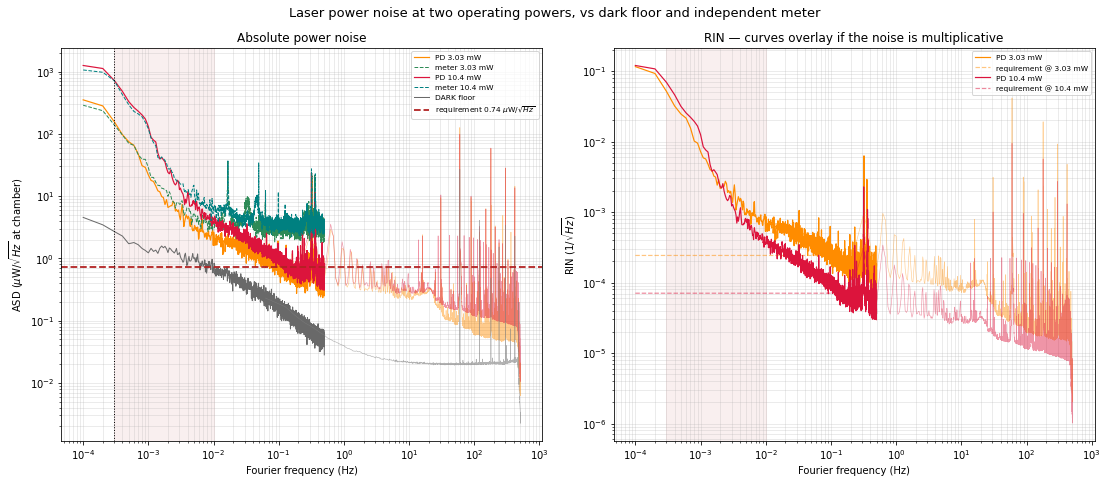

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.8))

# ---- left: absolute uW/sqrt(Hz) ------------------------------------------------
ax = axes[0]
for r in RUNS:
    ax.loglog(f_lo[1:], r['u_lo'][1:], lw=1.2, color=r['color'], label=f'PD {r["name"]}')
    ax.loglog(f_hi[1:], r['u_hi'][1:], lw=0.6, color=r['color'], alpha=0.45)
    ax.loglog(f_lo[1:], r['um_lo'][1:], lw=1.0, color=r['mcolor'], ls='--',
              label=f'meter {r["name"]}')
ax.loglog(f_lo[1:], RUNS[0]['udk_lo'][1:], lw=1.0, color='dimgray', label='DARK floor')
ax.loglog(f_hi[1:], RUNS[0]['udk_hi'][1:], lw=0.6, color='gray', alpha=0.6)
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.8,
           label=f'requirement {REQ_UW:.2f} $\\mu$W/$\\sqrt{{Hz}}$')
ax.axvspan(3e-4, 1e-2, color='firebrick', alpha=0.07)
ax.axvline(3 / SEG_LO_S, color='k', ls=':', lw=1.0)
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('ASD ($\\mu$W/$\\sqrt{Hz}$ at chamber)')
ax.set_title('Absolute power noise', fontsize=12)
ax.legend(fontsize=7.5, loc='upper right'); ax.grid(True, which='both', alpha=0.3)

# ---- right: RIN -- the discriminator -------------------------------------------
ax = axes[1]
for r in RUNS:
    ax.loglog(f_lo[1:], r['u_lo'][1:] * 1e-3 / r['P_mW'], lw=1.2, color=r['color'],
              label=f'PD {r["name"]}')
    ax.loglog(f_hi[1:], r['u_hi'][1:] * 1e-3 / r['P_mW'], lw=0.6, color=r['color'], alpha=0.45)
    ax.loglog(f_lo[1:], REQ_UW * 1e-3 / r['P_mW'] * np.ones_like(f_lo[1:]),
              lw=1.2, ls='--', color=r['color'], alpha=0.5,
              label=f'requirement @ {r["name"]}')
ax.axvspan(3e-4, 1e-2, color='firebrick', alpha=0.07)
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/$\\sqrt{Hz}$)')
ax.set_title('RIN — curves overlay if the noise is multiplicative', fontsize=12)
ax.legend(fontsize=7.5, loc='upper right'); ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Laser power noise at two operating powers, vs dark floor and independent meter',
             fontsize=13)
plt.tight_layout(); plt.show()

### Band table, both runs

In [6]:
BANDS = [(3e-4,1e-3),(1e-3,3e-3),(3e-3,1e-2),(1e-2,1e-1),(0.1,0.5),
         (0.5,2),(2,10),(10,50),(50,500)]

def band_med(ff, u, lo, hi):
    b = (ff > lo) & (ff < hi)
    return np.median(u[b]) if b.any() else np.nan

hdr = f"{'band':>18} |"
for r in RUNS:
    hdr += f" {r['short']+' PD':>9} | {r['short']+' meter':>11} |"
hdr += f" {'DARK':>8} | {'ratio':>7} | {'exp':>5}"
print(hdr); print('-' * len(hdr))
pratio = RUNS[1]['P_mW'] / RUNS[0]['P_mW']
for lo, hi in BANDS:
    use_lo = hi <= 0.5
    row = f'{lo*1e3:8.2f}-{hi*1e3:8.2f} mHz |'
    vals = []
    for r in RUNS:
        ff, u = (f_lo, r['u_lo']) if use_lo else (f_hi, r['u_hi'])
        v = band_med(ff, u, lo, hi); vals.append(v)
        m = band_med(f_lo, r['um_lo'], lo, hi) if use_lo else np.nan
        row += f' {v:9.3f} |' + (f' {m:11.3f} |' if np.isfinite(m) else f' {"--":>11} |')
    ffd, ud = (f_lo, RUNS[0]['udk_lo']) if use_lo else (f_hi, RUNS[0]['udk_hi'])
    row += f' {band_med(ffd, ud, lo, hi):8.3f} |'
    row += f' {vals[1]/vals[0]:6.2f}x | {pratio:4.2f}x'
    print(row)
print(f'\n(uW/sqrt(Hz); requirement {REQ_UW:.3f}.  "ratio" = {RUNS[1]["short"]}/{RUNS[0]["short"]} '
      f'PD ASD; "exp" = the power ratio {pratio:.2f}x expected if the noise is purely '
      f'multiplicative.)')

              band |    3mW PD |   3mW meter |   10mW PD |  10mW meter |     DARK |   ratio |   exp
---------------------------------------------------------------------------------------------------
    0.30-    1.00 mHz |    65.309 |      65.291 |   265.086 |     229.025 |    1.719 |   4.06x | 3.43x
    1.00-    3.00 mHz |     7.677 |      11.722 |    26.411 |      28.161 |    1.359 |   3.44x | 3.43x
    3.00-   10.00 mHz |     2.767 |       4.214 |     5.439 |       8.077 |    0.871 |   1.97x | 3.43x
   10.00-  100.00 mHz |     1.093 |       3.403 |     1.475 |       4.125 |    0.262 |   1.35x | 3.43x
  100.00-  500.00 mHz |     0.527 |       3.212 |     0.636 |       3.685 |    0.073 |   1.21x | 3.43x
  500.00- 2000.00 mHz |     0.485 |          -- |     0.635 |          -- |    0.035 |   1.31x | 3.43x
 2000.00-10000.00 mHz |     0.300 |          -- |     0.356 |          -- |    0.023 |   1.19x | 3.43x
10000.00-50000.00 mHz |     0.171 |          -- |     0.218 |          -- |    

### Reading the ratio column

- **ratio ≈ power ratio** → multiplicative. The absolute noise scales with operating
  power, so running at 10 mW costs you a proportionally larger absolute excess over a
  requirement that does *not* move. RIN is the invariant.
- **ratio ≈ 1** → additive. Something fixed dominates, and RIN improves with power.
- **ratio between** → a mix; the crossover frequency is where the additive floor takes
  over.

Remember what this cannot do: real laser RIN and a drifting transmission between laser
and diode are *both* multiplicative, so a ratio near the power ratio does not by itself
implicate the laser. The independent meter is the discriminator — where the two
instruments agree above the meter's own floor, the fluctuation is upstream of both.

## 4. Is the meter resolving, or on its quantization floor?

The meter comparison is only meaningful where the meter can actually see. StarLab logs
to fixed decimal places, so there is a quantization step; below it the record is a
staircase and its spectrum flattens onto a floor of roughly $q/\sqrt{12}$ rms spread
across the band. Where the meter sits on that floor it provides an **upper limit**,
not a measurement.

In [7]:
for r in RUNS:
    u  = np.unique(r['pm'])
    du = np.diff(u)
    q  = du.min() if len(du) else np.nan
    hf = (f_lo > 0.05) & (f_lo < 0.5)
    meas = np.median(r['um_lo'][hf])
    print(f"== {r['name']} meter ==")
    print(f"   header          : {r['pstats']}")
    print(f"   distinct values : {len(u)}   quantization step {q*1e3:.3f} uW")
    print(f"   record std      : {r['pm'].std()*1e3:9.3f} uW = {r['pm'].std()/q:.2f} steps")
    print(f"   q/sqrt(12)      : {q/np.sqrt(12)*1e3:9.3f} uW rms")
    print(f"   measured floor (50-500 mHz): {meas:.3f} uW/sqrt(Hz)"
          f"   [requirement {REQ_UW:.3f}]")
    print(f"   -> {'ABOVE requirement: corroborates only, cannot verify' if meas > REQ_UW else 'below requirement'}")
    print()

== 3.03 mW meter ==
   header          : {'Min': '3.010mW', 'Max': '3.060mW', 'Average': '3.031mW', 'Std.Dev.': '6.317uW', 'Total': '1174878', 'Duration': '021:45:19'}
   distinct values : 6   quantization step 10.000 uW
   record std      :     6.317 uW = 0.63 steps
   q/sqrt(12)      :     2.887 uW rms
   measured floor (50-500 mHz): 3.201 uW/sqrt(Hz)   [requirement 0.735]
   -> ABOVE requirement: corroborates only, cannot verify

== 10.4 mW meter ==
   header          : {'Min': '-10.00uW', 'Max': '10.48mW', 'Average': '10.40mW', 'Std.Dev.': '166.3uW', 'Total': '1755499', 'Duration': '032:30:37'}
   distinct values : 24   quantization step 0.900 uW
   record std      :   166.252 uW = 184.72 steps
   q/sqrt(12)      :     0.260 uW rms
   measured floor (50-500 mHz): 3.693 uW/sqrt(Hz)   [requirement 0.735]
   -> ABOVE requirement: corroborates only, cannot verify



## 5. Stability: raw scatter, drift, and what survives detrending

`rotor_stability_flat.ipynb` c9's summary applied to power. The gap between `drift` and
`std detrended` is the honest statement of how much of the instability is a slow trend
rather than noise.

In [8]:
print(f"{'series':>14} {'hours':>7} {'std':>12} {'drift':>15} {'std detr':>12}")
print('-' * 66)
rows = [('DARK', dk_y, 1e3 / RUNS[0]['cts_per_mW'])]
for r in RUNS:
    rows.append((f'{r["short"]} PD',    r['pd_y'], 1e3 / r['cts_per_mW']))
    rows.append((f'{r["short"]} meter', r['m_y'],  1e3))
for nm, y, scale in rows:
    ts = np.arange(len(y)) / FS_LO
    c  = np.polyfit(ts, y, 1)
    d  = y - np.polyval(c, ts)
    print(f'{nm:>14} {len(y)/3600:6.2f}h {y.std()*scale:10.2f}uW '
          f'{c[0]*3600*scale:+12.3f}uW/h {d.std()*scale:10.2f}uW')

        series   hours          std           drift     std detr
------------------------------------------------------------------
          DARK  21.53h       0.19uW       -0.001uW/h       0.19uW
        3mW PD  21.77h       6.01uW       +0.220uW/h       5.85uW
     3mW meter  21.75h       6.15uW       +0.267uW/h       5.92uW
       10mW PD  29.95h      22.58uW       -0.513uW/h      22.14uW
    10mW meter  31.59h      19.54uW       -0.490uW/h      19.02uW


## 6. Does the wander average down?

`rotor_stability_flat.ipynb` c13's test. If the fluctuation were white, averaging $N$
samples would narrow the scatter by $\sqrt{N}$. Where the measured std falls short of
that, the residual is correlated wander — it does not average away, and watching longer
buys less than it appears to.

In [9]:
print(f"{'boxcar':>8} |" + ''.join(f" {r['short']+' meas':>10} {'white':>9} {'ratio':>7} |" for r in RUNS))
print('-' * (10 + 30 * len(RUNS)))
for mins in [1, 5, 10, 30, 60]:
    line = f'{mins:6d} m |'
    for r in RUNS:
        y, scale = r['pd_y'], 1e3 / r['cts_per_mW']
        n = int(mins * 60 * FS_LO)
        if n >= len(y) // 2:
            line += f' {"--":>10} {"--":>9} {"--":>7} |'; continue
        sm = uniform_filter1d(y.astype(np.float64), size=n)[n // 2: -n // 2]
        meas, pred = sm.std() * scale, y.std() * scale / np.sqrt(n)
        line += f' {meas:9.3f}u {pred:8.3f}u {meas/pred:6.1f}x |'
    print(line)
print('\nratio = measured / white prediction.  1x = averages down like white noise;')
print('>>1x = correlated wander that does not average away.')

  boxcar |   3mW meas     white   ratio |  10mW meas     white   ratio |
----------------------------------------------------------------------
     1 m |     5.910u    0.775u    7.6x |    22.500u    2.915u    7.7x |
     5 m |     5.815u    0.347u   16.8x |    22.163u    1.303u   17.0x |
    10 m |     5.666u    0.245u   23.1x |    21.521u    0.922u   23.4x |
    30 m |     4.933u    0.142u   34.8x |    18.543u    0.532u   34.8x |
    60 m |     3.751u    0.100u   37.5x |    14.624u    0.376u   38.9x |

ratio = measured / white prediction.  1x = averages down like white noise;
>>1x = correlated wander that does not average away.


## 7. Spectral lines (tagged *electronic* if also present in the dark record)

In [10]:
for r in RUNS:
    m = f_hi > 0.2
    fm, um_on, um_dk = f_hi[m], r['u_hi'][m], r['udk_hi'][m]
    base = median_filter(um_on, size=101)
    pk, _ = find_peaks(um_on / base, height=8, distance=3)
    order = np.argsort(um_on[pk])[::-1]
    print(f"== {r['name']} ==")
    print(f"{'f (Hz)':>9} | {'ON uW/rtHz':>11} | {'DARK':>10} | {'x req':>7} | origin")
    print('-' * 62)
    for i in pk[order][:10]:
        elec = um_dk[i] > 0.5 * um_on[i]
        print(f'{fm[i]:9.2f} | {um_on[i]:11.3f} | {um_dk[i]:10.3f} | {um_on[i]/REQ_UW:6.1f}x | '
              f'{"electronic (in dark)" if elec else "optical"}')
    print()

== 3.03 mW ==
   f (Hz) |  ON uW/rtHz |       DARK |   x req | origin
--------------------------------------------------------------
    59.94 |     126.417 |     27.029 |  171.9x | optical
   179.81 |      58.059 |      0.484 |   79.0x | optical
   299.69 |      28.082 |      3.415 |   38.2x | optical
   419.50 |      14.475 |      2.096 |   19.7x | optical
    89.12 |       9.541 |      0.020 |   13.0x | optical
    30.69 |       9.468 |      0.020 |   12.9x | optical
    91.25 |       8.213 |      0.021 |   11.2x | optical
   182.50 |       7.081 |      0.021 |    9.6x | optical
   150.56 |       6.284 |      0.021 |    8.5x | optical
   273.75 |       4.906 |      0.020 |    6.7x | optical

== 10.4 mW ==
   f (Hz) |  ON uW/rtHz |       DARK |   x req | origin
--------------------------------------------------------------
    59.94 |      98.618 |     26.654 |  134.1x | optical
   179.69 |      59.161 |      0.250 |   80.5x | optical
   299.50 |      28.364 |      1.779 |   38.6x | 

## 8. PD vs meter: fiducial alignment and in-band correlation

The meter's internal clock is wrong (the StarLab header reads 2006), so the records
cannot be aligned by absolute timestamp. A deliberate beam block puts an unambiguous
edge in **both**, and the offset is read straight off. Blocks at both ends additionally
give the clock drift across the run.

The correlation is computed **in-band** — both series smoothed and detrended first —
because broadband it is a weak test: the meter is quantization-limited above ~1 mHz and
shares little with the PD there.

In [11]:
SMOOTH_S = 100
for r in RUNS:
    print(f"== {r['name']} ==")
    bp, bm = r['pd_blocks'], r['m_blocks']
    off, pairs = match_fiducials(bp, bm)
    if off is None:
        print(f'  no fiducial in both (PD {len(bp)} blocks, meter {len(bm)})')
    else:
        print(f'  FIDUCIAL: meter_t = PD_t {off:+.1f} s   ({off/3600:+.2f} h), '
              f'{len(pairs)} block(s) matched')
        for ip, jm in pairs:
            print(f'      PD  t={bp[ip]["start_s"]:9.1f} s ({bp[ip]["dur_s"]:4.1f} s)  <->  '
                  f'meter t={bm[jm]["start_s"]:9.1f} s ({bm[jm]["dur_s"]:4.1f} s)')
        if len(pairs) > 1:
            d = ((bm[pairs[-1][1]]['start_s'] - bp[pairs[-1][0]]['start_s']) -
                 (bm[pairs[0][1]]['start_s']  - bp[pairs[0][0]]['start_s']))
            print(f'      clock drift across the run: {d:+.1f} s')
        # consistency: does that offset put the two records on top of each other?
        pd_span = (0.0, len(r['pd']['y_lo']) / FS_LO)
        m_span  = (-off, (len(r['pm_1']) / FS_LO) - off)   # meter mapped into PD time
        print(f'      sanity: PD spans {pd_span[0]/3600:.2f}-{pd_span[1]/3600:.2f} h; '
              f'meter maps to {m_span[0]/3600:.2f}-{m_span[1]/3600:.2f} h in PD time')
        print(f'      unmatched blocks: PD {len(bp)-len(pairs)}, meter {len(bm)-len(pairs)} '
              f'(expected if one record starts later than the other)')

    n = min(len(r['pd_y']), len(r['m_y']))
    a = r['pd_y'][:n] / r['cts_per_mW']
    b = r['m_y'][:n]
    ns = int(SMOOTH_S * FS_LO)
    a = uniform_filter1d(a, ns)[ns:-ns]; b = uniform_filter1d(b, ns)[ns:-ns]
    ts = np.arange(len(a))
    a = a - np.polyval(np.polyfit(ts, a, 1), ts)
    b = b - np.polyval(np.polyfit(ts, b, 1), ts)
    if a.std() > 0 and b.std() > 0:
        xc  = correlate(a - a.mean(), b - b.mean(), mode='full')
        lag = int(np.arange(-len(a) + 1, len(a))[np.argmax(xc)])
        s1, s2 = slice(max(0, lag), None), slice(max(0, -lag), None)
        nl = min(len(a[s1]), len(b[s2]))
        rr = float(np.corrcoef(a[s1][:nl], b[s2][:nl])[0, 1]) if nl > 10 else np.nan
        print(f'  in-band ({SMOOTH_S} s smoothing, detrended): best lag {lag:+d} s, r = {rr:.3f}')
    print()

== 3.03 mW ==
  no fiducial in both (PD 3 blocks, meter 0)
  in-band (100 s smoothing, detrended): best lag +12 s, r = 0.945

== 10.4 mW ==
  FIDUCIAL: meter_t = PD_t +9114.0 s   (+2.53 h), 1 block(s) matched
      PD  t= 107849.0 s (10.0 s)  <->  meter t= 116963.0 s (11.0 s)
      sanity: PD spans 0.00-30.00 h; meter maps to -2.53-29.98 h in PD time
      unmatched blocks: PD 0, meter 2 (expected if one record starts later than the other)
  in-band (100 s smoothing, detrended): best lag -5975 s, r = 0.990



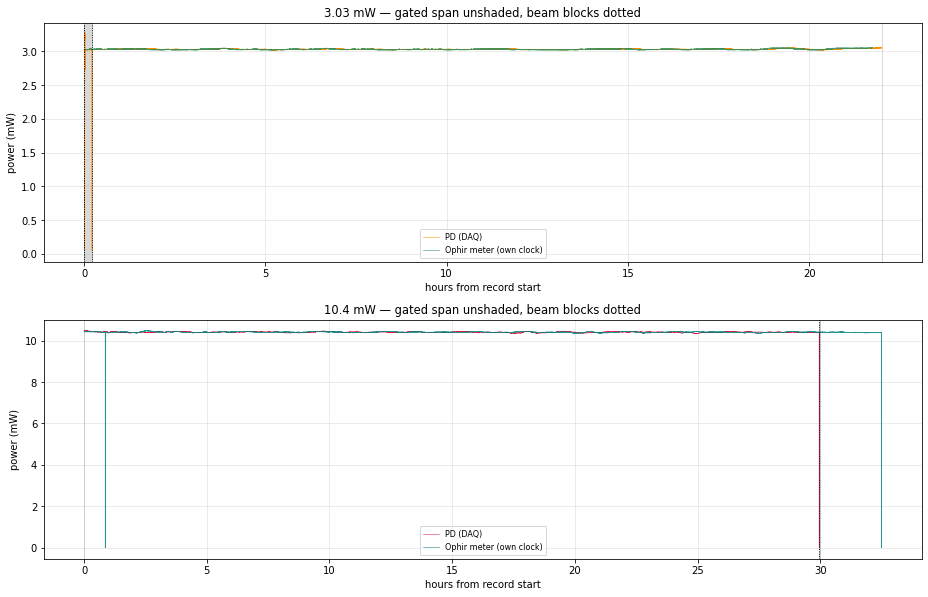

In [12]:
fig, axes = plt.subplots(len(RUNS), 1, figsize=(13, 4.2 * len(RUNS)), squeeze=False)
for ax, r in zip(axes[:, 0], RUNS):
    t_h = np.arange(len(r['pd']['y_lo'])) / FS_LO / 3600
    ax.plot(t_h, r['pd']['y_lo'] / r['cts_per_mW'], lw=0.5, color=r['color'], label='PD (DAQ)')
    ax.plot((r['gp'] - r['gp'][0]) / 3600, r['pm_1'], lw=0.6, color=r['mcolor'],
            alpha=0.85, label='Ophir meter (own clock)')
    ax.axvspan(0, r['pd_i0'] / 3600, color='gray', alpha=0.3)
    ax.axvspan(r['pd_i1'] / 3600, t_h[-1], color='gray', alpha=0.3)
    for b in r['pd_blocks']:
        ax.axvline(b['start_s'] / 3600, color='k', ls=':', lw=0.9)
    ax.set_xlabel('hours from record start'); ax.set_ylabel('power (mW)')
    ax.set_title(f'{r["name"]} — gated span unshaded, beam blocks dotted', fontsize=11.5)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Shot-noise context

In [13]:
for r in RUNS:
    hf = (f_hi > 100) & (f_hi < 400)
    floor_uW  = float(np.median(r['u_hi'][hf]))
    floor_rin = floor_uW * 1e-3 / r['P_mW']
    shot_rin  = np.sqrt(2 * E_CHARGE / (RESPONSIVITY * r['P_mW'] * 1e-3))
    print(f"{r['name']:>9}: floor (100-400 Hz) {floor_uW:.4f} uW/rtHz = {floor_rin:.2e} /rtHz | "
          f"shot {shot_rin:.2e} /rtHz | {floor_rin/shot_rin:5.0f}x above shot noise")
print('\nimplementation-limited, not fundamental.')

  3.03 mW: floor (100-400 Hz) 0.0593 uW/rtHz = 1.96e-05 /rtHz | shot 1.23e-08 /rtHz |  1591x above shot noise
  10.4 mW: floor (100-400 Hz) 0.1081 uW/rtHz = 1.04e-05 /rtHz | shot 6.63e-09 /rtHz |  1567x above shot noise

implementation-limited, not fundamental.


## 10. Where this leaves us

- **The data-quality gate is not optional.** Beam blocks and the laser turn-on both
  have to come out *before* the spectrum, and the gate must handle a block that closes
  the record as well as one that opens it. Any low-frequency claim made without it is a
  property of the transient, not of the laser.
- **The band is actually covered.** 10000 s segments give 0.1 mHz resolution,
  trustworthy down to 0.3 mHz — the bottom of the requirement band.
- **The ratio column is the new physics.** Compare it to the power ratio: that is what
  says whether the absolute excess grows with operating power, which decides how much
  the requirement actually costs at the power you intend to run.
- **Where the meter is above its own quantization floor it corroborates the PD**, and
  agreement between two instruments with unrelated systematics is the strongest
  available statement that the fluctuation is upstream of both. Where it is on that
  floor it sets an upper limit only — and its floor sits above the requirement, so the
  meter can never verify the requirement by itself.
- **The excess is concentrated at the bottom of the band**, which is where any
  stabilisation effort has to be aimed. The broadband floor is far from shot noise, so
  there is headroom there.

**Next.** A second photodiode on its own wedged pickoff would extend the
two-instrument cross-check across the whole band rather than just the bottom decade,
since it would not carry the meter's 10 µW quantization floor.